# Notebook 02: 方势垒模拟

## 高斯波包入射方势垒的含时演化

---

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from config import SimParams, tunneling, above_barrier
from potentials import get_potential
from propagator import propagate
from visualization import (
    set_style, plot_potential_and_wavepacket,
    animate_evolution, plot_TR_evolution,
    plot_momentum_spectrum, plot_snapshots
)

set_style()

## 1. 隧穿区域 (E < V₀)

方势垒参数：$V_0 = 15$，$a = -1$，$b = 1$，势垒宽度 $L = 2$

波包参数：$k_0 = 5$，$E_{\text{kin}} = 12.5 < V_0$

预期：大部分反射，小部分隧穿透射

In [2]:
p_tunnel = tunneling()
print(f'V0 = {p_tunnel.V0}, E_kinetic = {p_tunnel.E_kinetic:.2f}')
print(f'E/V0 = {p_tunnel.E_kinetic/p_tunnel.V0:.3f}')
print(f'衰减常数 κ = {np.sqrt(2*(p_tunnel.V0 - p_tunnel.E_kinetic)):.3f}')
print(f'势垒宽度 L = {p_tunnel.barrier_b - p_tunnel.barrier_a:.1f}')
print(f'粗略透射率 T ~ exp(-2κL) ≈ {np.exp(-2*np.sqrt(2*(p_tunnel.V0-p_tunnel.E_kinetic))*(p_tunnel.barrier_b-p_tunnel.barrier_a)):.6f}')

V0 = 15.0, E_kinetic = 12.50
E/V0 = 0.833
衰减常数 κ = 2.236
势垒宽度 L = 2.0
粗略透射率 T ~ exp(-2κL) ≈ 0.000130


In [3]:
result_tunnel = propagate(p_tunnel, 'square')

In [4]:
print(f'最终透射率: T = {result_tunnel.T_values[-1]:.6f}')
print(f'最终反射率: R = {result_tunnel.R_values[-1]:.6f}')
print(f'T + R = {result_tunnel.T_values[-1] + result_tunnel.R_values[-1]:.6f}')
print(f'概率守恒: ∫|ψ|²dx = {result_tunnel.norm_values[-1]:.8f}')

最终透射率: T = 0.000871
最终反射率: R = 0.999127
T + R = 0.999998
概率守恒: ∫|ψ|²dx = 0.99999832


### 波包演化快照

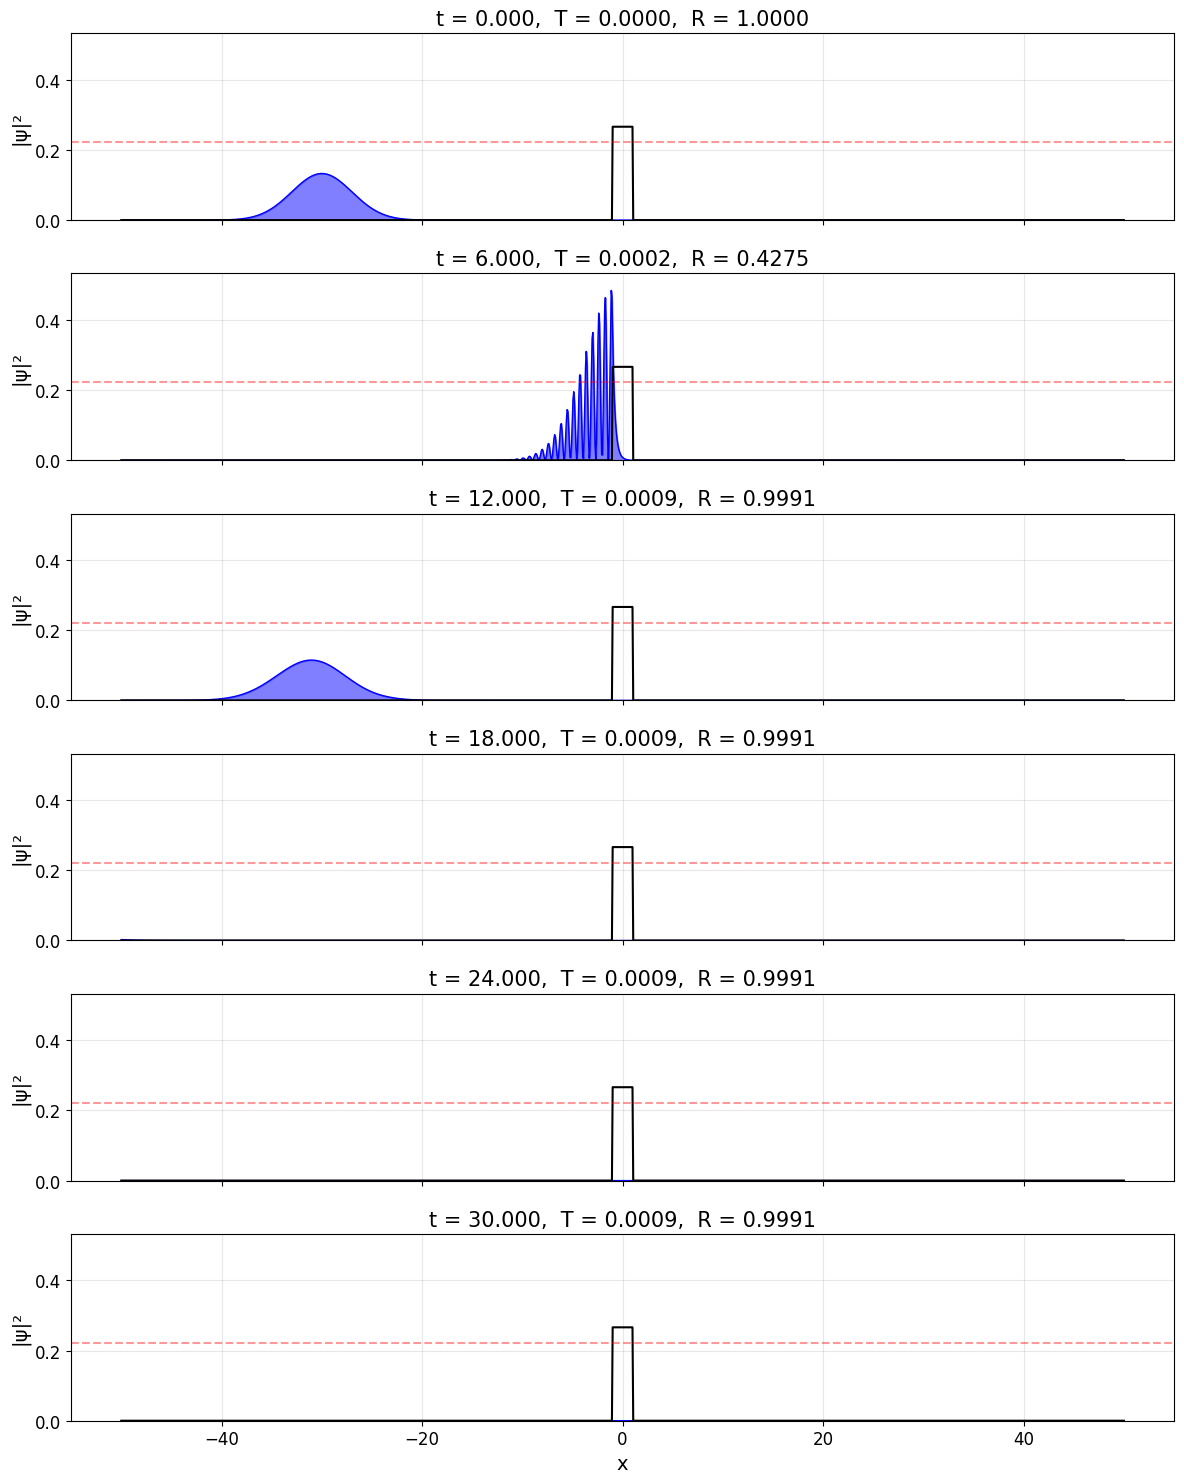

In [5]:
fig = plot_snapshots(result_tunnel, n_snapshots=6, x_range=(-50, 50))
plt.show()

### 透射率/反射率演化

C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 36879 (\N{CJK UNIFIED IDEOGRAPH-900F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:132: UserWarning: Glyph 28436 (\N{CJK UNIFIED IDEOGRAPH-6F14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\Op

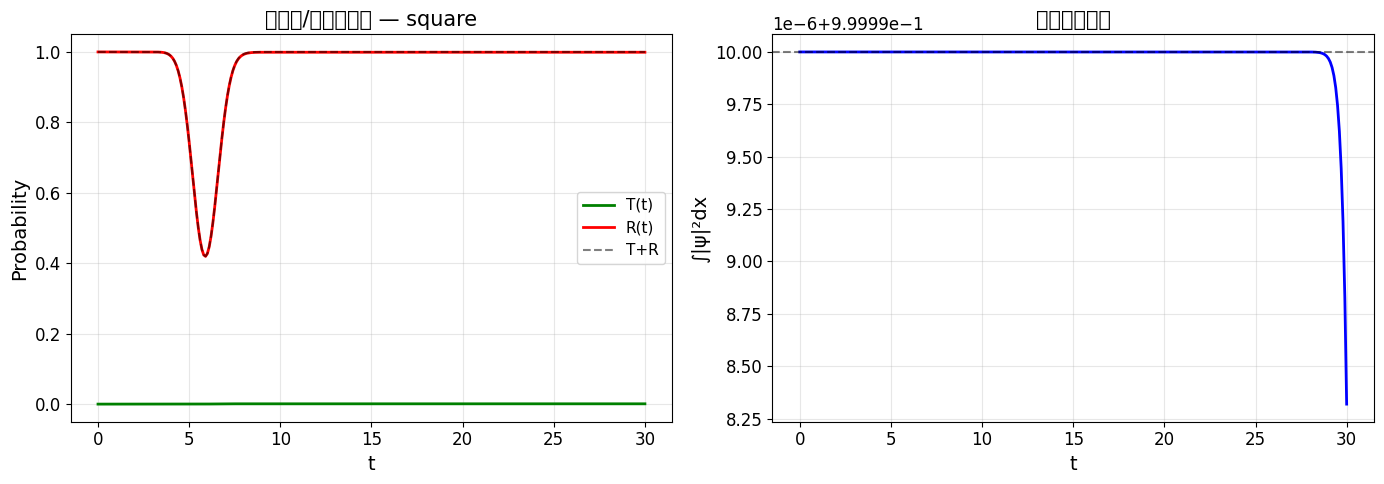

In [6]:
fig = plot_TR_evolution(result_tunnel)
plt.show()

### 动量谱演化

C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:158: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:158: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:158: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:158: UserWarning: Glyph 28436 (\N{CJK UNIFIED IDEOGRAPH-6F14}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\OpenCodeProjects\quantum_barrier_sim\visualization.py:158: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\Desktop\Op

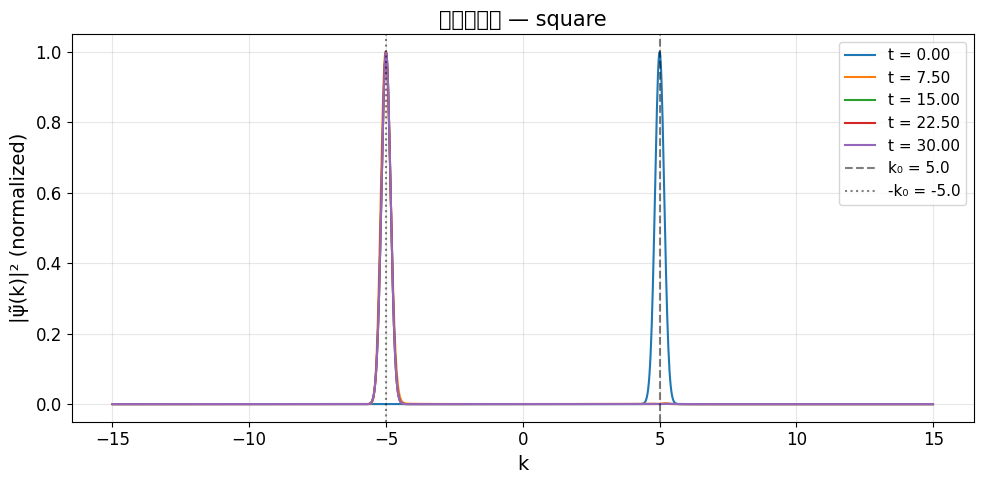

In [7]:
fig = plot_momentum_spectrum(result_tunnel, k_range=(-15, 15))
plt.show()

## 2. 经典透射区域 (E > V₀)

$V_0 = 5$，$E_{\text{kin}} = 12.5 > V_0$

预期：大部分透射，但仍存在量子反射

In [8]:
p_above = above_barrier()
print(f'V0 = {p_above.V0}, E_kinetic = {p_above.E_kinetic:.2f}')
print(f'E/V0 = {p_above.E_kinetic/p_above.V0:.3f}')

V0 = 5.0, E_kinetic = 12.50
E/V0 = 2.500


In [9]:
result_above = propagate(p_above, 'square')

In [10]:
print(f'最终透射率: T = {result_above.T_values[-1]:.6f}')
print(f'最终反射率: R = {result_above.R_values[-1]:.6f}')
print(f'量子反射占比: {result_above.R_values[-1]/(result_above.T_values[-1]+result_above.R_values[-1])*100:.2f}%')

最终透射率: T = 0.944539
最终反射率: R = 0.055460
量子反射占比: 5.55%


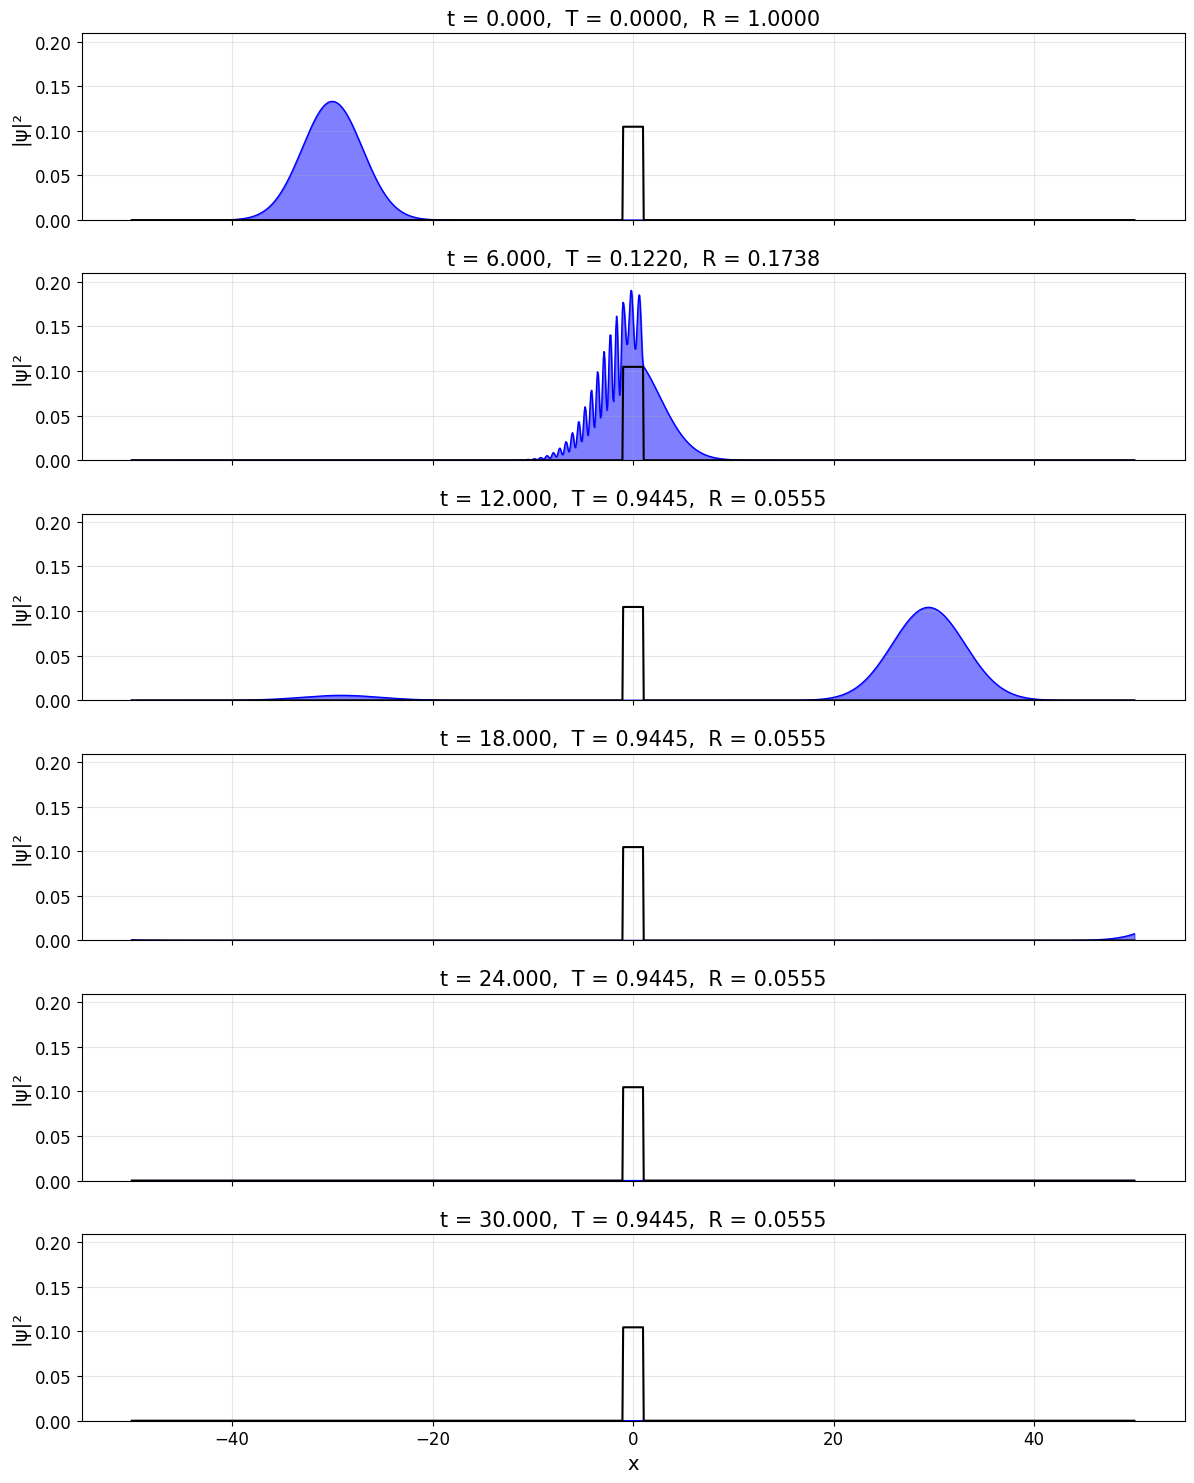

In [11]:
fig = plot_snapshots(result_above, n_snapshots=6, x_range=(-50, 50))
plt.show()

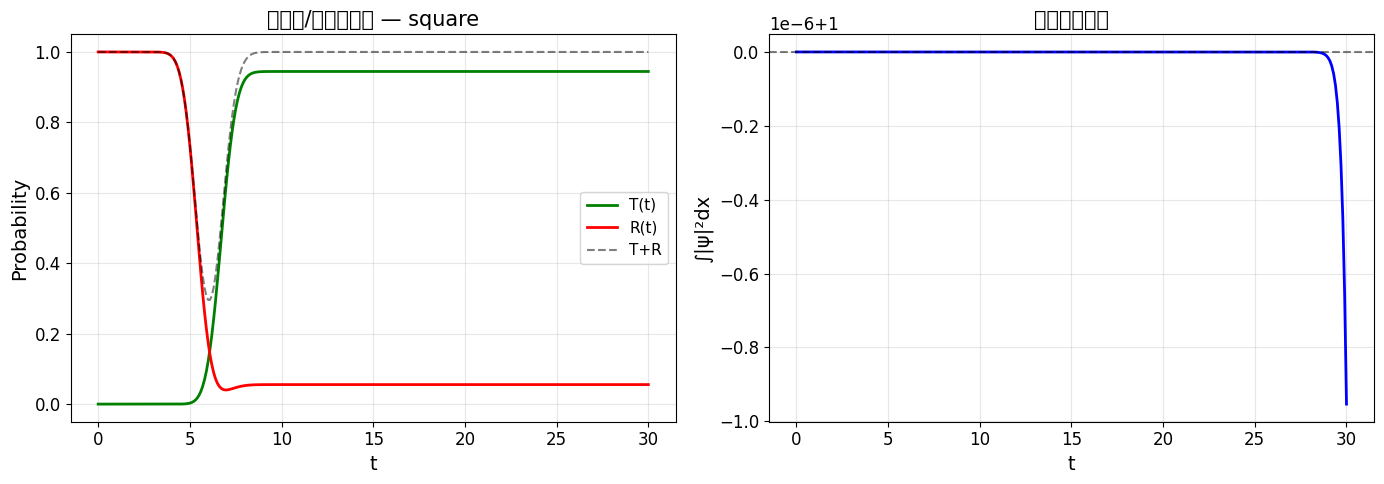

In [12]:
fig = plot_TR_evolution(result_above)
plt.show()

## 3. 势垒宽度对隧穿率的影响

In [13]:
widths = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
T_widths = []

for w in widths:
    p_w = SimParams(V0=15.0, k0=5.0, barrier_a=-w/2, barrier_b=w/2)
    res = propagate(p_w, 'square')
    T_widths.append(res.T_values[-1])
    print(f'Width = {w:.1f}, T = {res.T_values[-1]:.6f}')

Width = 0.5, T = 0.292970
Width = 1.0, T = 0.025689
Width = 1.5, T = 0.004871
Width = 2.0, T = 0.000871
Width = 3.0, T = 0.000454
Width = 4.0, T = 0.000401


C:\Users\User1\AppData\Local\Temp\ipykernel_23584\1765789529.py:13: UserWarning: Glyph 38567 (\N{CJK UNIFIED IDEOGRAPH-96A7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_23584\1765789529.py:13: UserWarning: Glyph 31359 (\N{CJK UNIFIED IDEOGRAPH-7A7F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_23584\1765789529.py:13: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_23584\1765789529.py:13: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_23584\1765789529.py:13: UserWarning: Glyph 22418 (\N{CJK UNIFIED IDEOGRAPH-5792}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User1\AppData\Local\Temp\ipykernel_23584\1765789529.py:13: UserWarning: Glyph 23485 (\

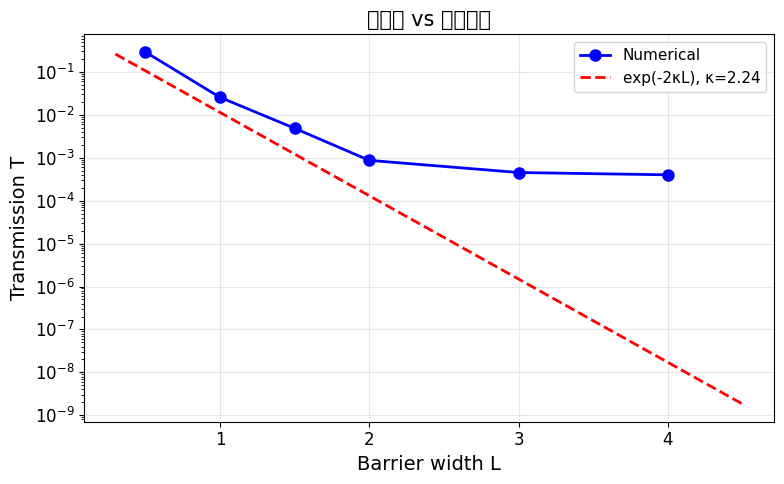

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(widths, T_widths, 'bo-', linewidth=2, markersize=8, label='Numerical')

kappa = np.sqrt(2 * (15.0 - 0.5 * 5.0**2))
w_fine = np.linspace(0.3, 4.5, 100)
T_analytic = np.exp(-2 * kappa * w_fine)
ax.semilogy(w_fine, T_analytic, 'r--', linewidth=2, label=f'exp(-2κL), κ={kappa:.2f}')

ax.set_xlabel('Barrier width L')
ax.set_ylabel('Transmission T')
ax.set_title('隧穿率 vs 势垒宽度')
ax.legend()
plt.tight_layout()
plt.show()